In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [ ]:
MODEL_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/cnn_model.h5"
)

TOKENIZER_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/models/tokenizer.pkl"
)

cnn_model = load_model(
    MODEL_PATH
)

with open(
    TOKENIZER_PATH,
    "rb"
) as f:

    tokenizer = pickle.load(f)

print("CNN Loaded")
print("Tokenizer Loaded")

CNN Loaded
Tokenizer Loaded


In [ ]:
TEST_PATH = (
    "/content/drive/MyDrive/FP_AI_2026/data/test.csv"
)

test_df = pd.read_csv(
    TEST_PATH
)

print(
    test_df.shape
)

test_df.head()

(100, 2)


,Sample_Code,Label
0,#include <iostream>\n#include <vector>\n\nusin...,1
1,import Java.util.Scanner;\n\npublic class Main...,0
2,public class BinarySearchTree {\n\n // Root...,0
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1
4,import Java.util.Scanner;\n\npublic class Plus...,1


In [ ]:
X_test = test_df[
    "Sample_Code"
]

y_test = test_df[
    "Label"
]

In [ ]:
MAX_LEN = 500

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [ ]:
y_prob = cnn_model.predict(
    X_test_pad,
    verbose=1
)

y_prob = y_prob.flatten()

preds = (
    y_prob > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


In [ ]:
print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "Human",
            "AI"
        ]
    )
)

              precision    recall  f1-score   support

       Human       0.98      0.94      0.96        50
          AI       0.94      0.98      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [ ]:
error_df = test_df.copy()

error_df["Prediction"] = preds

error_df["Probability_AI"] = y_prob

error_df["Correct"] = (
    error_df["Label"]
    ==
    error_df["Prediction"]
)

error_df.head()

,Sample_Code,Label,Prediction,Probability_AI,Correct
0,#include <iostream>\n#include <vector>\n\nusin...,1,1,0.999476,True
1,import Java.util.Scanner;\n\npublic class Main...,0,0,0.000021,True
2,public class BinarySearchTree {\n\n // Root...,0,1,0.657334,False
3,#include <iostream>\n#include <cmath>\n\ndoubl...,1,1,0.999573,True
4,import Java.util.Scanner;\n\npublic class Plus...,1,1,0.994605,True


In [ ]:
print(
    "Total Data:",
    len(error_df)
)

print(
    "Correct:",
    error_df["Correct"].sum()
)

print(
    "Wrong:",
    (~error_df["Correct"]).sum()
)

Total Data: 100
Correct: 96
Wrong: 4


In [ ]:
fp_df = error_df[
    (error_df["Label"] == 0)
    &
    (error_df["Prediction"] == 1)
]

print(
    "False Positive:",
    len(fp_df)
)

False Positive: 3


In [ ]:
fn_df = error_df[
    (error_df["Label"] == 1)
    &
    (error_df["Prediction"] == 0)
]

print(
    "False Negative:",
    len(fn_df)
)

False Negative: 1


In [ ]:
cm = confusion_matrix(
    y_test,
    preds
)

cm

array([[47,  3],
       [ 1, 49]])

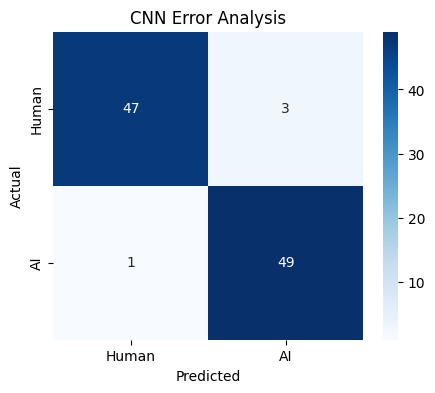

In [ ]:
plt.figure(
    figsize=(5,4)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Human",
        "AI"
    ],
    yticklabels=[
        "Human",
        "AI"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "CNN Error Analysis"
)

plt.show()

In [ ]:
for idx,row in fp_df.iterrows():

    print("="*120)

    print(
        f"INDEX : {idx}"
    )

    print(
        f"TRUE LABEL : {row['Label']}"
    )

    print(
        f"PREDICTION : {row['Prediction']}"
    )

    print(
        f"AI PROBABILITY : {row['Probability_AI']:.4f}"
    )

    print("\nCODE:\n")

    print(
        row["Sample_Code"]
    )

INDEX : 2
TRUE LABEL : 0
PREDICTION : 1
AI PROBABILITY : 0.6573

CODE:

public class BinarySearchTree {

    // Root of BST
    BstNode root;

    BinarySearchTree() {
        root = null;
    }

    void Insert(int data) {
        root = Insert(root, data);
    }

    BstNode Insert(BstNode root, int data) {

        if (root == null) {
            root = new BstNode(data);
        } else if (data < root.data)
            root.Left = Insert(root.Left, data);
        else if (data > root.data)
            root.Right = Insert(root.Right, data);

        return root;
    }

    void InOrder() {
        InOrder(root);
    }

    void InOrder(BstNode root) {
        if (root != null) {
            InOrder(root.Left);
            System.out.print(root.data + " ");
            InOrder(root.Right);
        }
    }

    void PreOrder() {
        PreOrder(root);
    }

    void PreOrder(BstNode root) {
        if (root == null)
            return;
        System.out.print(root.data + " ");
    

In [ ]:
for idx,row in fn_df.iterrows():

    print("="*120)

    print(
        f"INDEX : {idx}"
    )

    print(
        f"TRUE LABEL : {row['Label']}"
    )

    print(
        f"PREDICTION : {row['Prediction']}"
    )

    print(
        f"AI PROBABILITY : {row['Probability_AI']:.4f}"
    )

    print("\nCODE:\n")

    print(
        row["Sample_Code"]
    )

INDEX : 63
TRUE LABEL : 1
PREDICTION : 0
AI PROBABILITY : 0.4598

CODE:

// =============================================================
// Dynamic Programming: Unique Paths
// =============================================================
// A robot on an m x n grid starts at the top-left (0,0) and
// must reach the bottom-right (m-1, n-1). It can only move
// right or down. Count the number of distinct paths.
//
// Subproblem: dp[i][j] = number of paths to reach cell (i, j)
//
// Recurrence:
//   dp[0][j] = 1  (only one way along top row: all rights)
//   dp[i][0] = 1  (only one way along left column: all downs)
//   dp[i][j] = dp[i-1][j] + dp[i][j-1]
//
// Mathematical shortcut: C(m+n-2, m-1)  (combinatorics)
//
// Extension: Unique Paths II — grid contains obstacles ('1' blocks)
//
// Time:  O(m * n)  |  Space: O(m * n), reducible to O(n)
// =============================================================

#include <iostream>
#include <vector>
#include <algorithm>

// ----------------

In [ ]:
summary = pd.DataFrame({

    "Model":[
        "CNN"
    ],

    "False_Positive":[
        len(fp_df)
    ],

    "False_Negative":[
        len(fn_df)
    ],

    "Total_Error":[
        len(fp_df)+len(fn_df)
    ]
})

summary

,Model,False_Positive,False_Negative,Total_Error
0,CNN,3,1,4


In [ ]:
SAVE_DIR = (
    "/content/drive/MyDrive/FP_AI_2026/compare/"
)

fp_df.to_csv(
    SAVE_DIR + "cnn_false_positive.csv",
    index=False
)

fn_df.to_csv(
    SAVE_DIR + "cnn_false_negative.csv",
    index=False
)

summary.to_csv(
    SAVE_DIR + "cnn_error_summary.csv",
    index=False
)

print("Saved!")

Saved!
